===== 无正则化多元线性回归结果 =====
训练集MSE: 4683203783.5043
测试集MSE: 4908476721.1566
测试集R²: 0.6254


D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Weixin\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

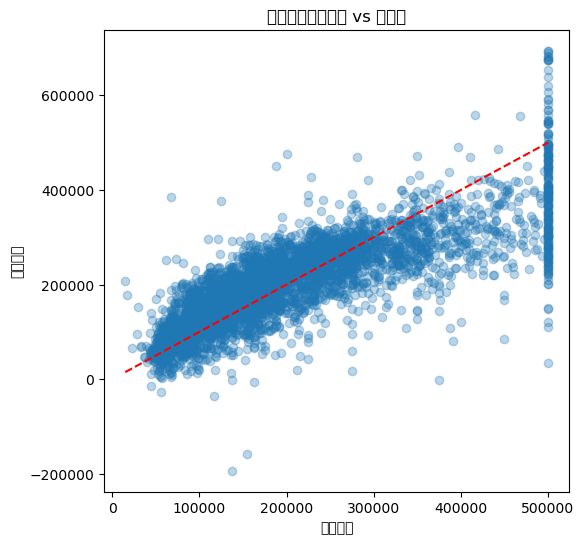

In [4]:
# 1.导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 2.线性回归类
class LinearRegression:
    def __init__(self):
        self.theta = None

    def fit(self, X, y):
        # 正规方程求解
        XTX = X.T @ X
        XTy = X.T @ y
        self.theta = np.linalg.inv(XTX) @ XTy

    def predict(self, X):
        return X @ self.theta

# 载入加州房价数据
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# 数据预处理
# 填充缺失值
df.fillna(df.median(numeric_only=True), inplace=True)
# 把分类特征转为数值
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

# 分离特征和目标变量
X = df.drop("median_house_value", axis=1).values
y = df["median_house_value"].values.reshape(-1, 1)

# 3. 划分训练集/测试集、标准化
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 给特征加偏置项
X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_scaled = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

# 4. 训练模型
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. 预测与评估
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("===== 无正则化多元线性回归结果 =====")
print(f"训练集MSE: {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"测试集MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"测试集R²: {r2_score(y_test, y_test_pred):.4f}")

# 6. 可视化（比较真实值预测值）
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("真实房价")
plt.ylabel("预测房价")
plt.title("无正则化：比较真实值与预测值")
plt.show()